# MVP de Machine Learning & Analytics - Previsão de Churn de Clientes

## 1. Apresentação do Problema
O objetivo deste MVP é desenvolver um modelo preditivo capaz de identificar clientes com alta probabilidade de cancelar seus contratos (*churn*).

* **Tipo de Tarefa:** Classificação Binária (0: Permanece, 1: Cancela).
* **Variável-Alvo:** `churn`.
* **Justificativa de ML:** O comportamento de cancelamento não segue uma regra estática (como "cancelar apenas após 3 meses"). Ele envolve interações complexas entre tempo de contrato, gastos e suporte acionado. O Machine Learning permite mapear essas relações não-lineares.
* **Premissas e Hipóteses:** Assume-se que clientes com contratos mensais e alto número de reclamações no suporte possuem maior propensão ao cancelamento.

## 2. Apresentação dos Dados
Os dados simulam um cenário real de uma empresa de SaaS (Software as a Service) com 1.000 clientes ativos e inativos.
* **Quantidade de registros:** 1.000
* **Atributos:** `tempo_contrato` (meses), `gasto_mensal` (R$), `chamados_suporte` (inteiro), `tipo_contrato` (Mensal/Anual).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Definição da semente global para reprodutibilidade
SEED = 42
np.random.seed(SEED)

URL_DATASET = "https://raw.githubusercontent.com/felipehsouza-dev/MVP/refs/heads/main/churn_clientes_saas.csv"

df = pd.read_csv(URL_DATASET)

print(f"Dataset carregado com sucesso via GitHub! Formato: {df.shape}")

Dataset carregado com sucesso via GitHub! Formato: (1000, 5)


## 3. Análise Exploratória Inicial
Nesta etapa, validamos a distribuição das variáveis, a presença de valores nulos e o balanço da nossa variável target.

--- Primeiras Linhas ---
   tempo_contrato  gasto_mensal  chamados_suporte tipo_contrato  churn
0              39    239.241100                 8        Mensal      1
1              52    403.100719                 9        Mensal      1
2              29    337.712611                 7        Mensal      1
3              15    412.270100                 7        Mensal      1
4              43    456.417976                 0         Anual      0

--- Estatísticas Descritivas ---
       tempo_contrato  gasto_mensal  chamados_suporte        churn
count     1000.000000   1000.000000        1000.00000  1000.000000
mean        30.582000    280.331662           4.46500     0.624000
std         17.024838    127.570949           2.81295     0.484622
min          1.000000     50.106886           0.00000     0.000000
25%         16.000000    172.757748           2.00000     0.000000
50%         31.000000    288.639393           4.00000     1.000000
75%         45.000000    387.426945           

/tmp/ipykernel_2720/2010572540.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set2')


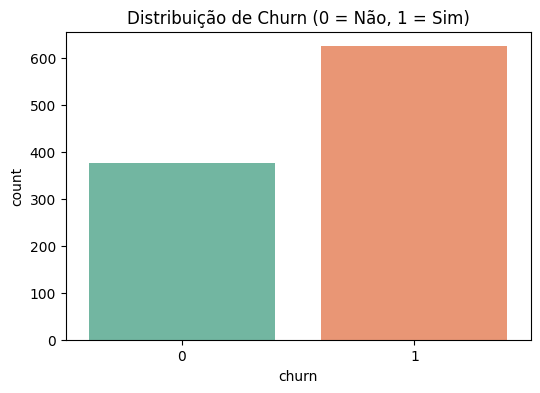

In [ ]:
# Visualização das primeiras linhas
print("--- Primeiras Linhas ---")
print(df.head())

# Estatísticas descritivas
print("\n--- Estatísticas Descritivas ---")
print(df.describe())

# Verificação de nulos
print("\n--- Valores Ausentes ---")
print(df.isnull().sum())

# Distribuição da variável alvo
print("\n--- Distribuição da Variável Target (Churn) ---")
print(df['churn'].value_counts(normalize=True))

# Plot da distribuição
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Distribuição de Churn (0 = Não, 1 = Sim)')
plt.show()

## 4. Preparação e Divisão dos Dados
Para evitar o **vazamento de dados (Data Leakage)**, dividiremos a base em treino (80%) e teste (20%) antes de qualquer transformação.
As transformações serão aplicadas de forma reprodutível utilizando o `ColumnTransformer` dentro de um `Pipeline`.

* **Variáveis Numéricas:** Aplicação de `StandardScaler` (padronização).
* **Variáveis Categóricas:** Aplicação de `OneHotEncoder` para conversão em colunas binárias.

In [ ]:
# Separação de features (X) e target (y)
X = df.drop(columns=['churn'])
y = df['churn']

# Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Definição das colunas por tipo
num_features = ['tempo_contrato', 'gasto_mensal', 'chamados_suporte']
cat_features = ['tipo_contrato']

# Criação dos pipelines de processamento
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combinador de transformações
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print("Pipelines de pré-processamento configurados com sucesso!")

Pipelines de pré-processamento configurados com sucesso!


## 5. Modelagem e Treinamento
Treinaremos três modelos:
1. **Baseline:** Um classificador ingênuo (`DummyClassifier`) que apenas chuta a classe majoritária.
2. **Candidato 1:** Regressão Logística (Modelo Linear).
3. **Candidato 2:** Random Forest (Modelo baseado em árvores).

In [ ]:
# 1. Baseline
baseline = Pipeline(steps=[('preprocessor', preprocessor), ('model', DummyClassifier(strategy='most_frequent'))])
baseline.fit(X_train, y_train)

# 2. Regressão Logística
lr_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', LogisticRegression(random_state=SEED))])
lr_model.fit(X_train, y_train)

# 3. Random Forest
rf_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=SEED))])
rf_model.fit(X_train, y_train)

print("Todos os modelos foram treinados com sucesso!")

Todos os modelos foram treinados com sucesso!


## 6. Otimização de Hiperparâmetros
Realizaremos uma busca em grade (`GridSearchCV`) utilizando validação cruzada com 5 dobras (*5-fold CV*) para otimizar os parâmetros do modelo Random Forest.

In [ ]:
# Grade de parâmetros do Random Forest (referenciando o passo 'model' do pipeline)
param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
best_rf_model = grid_search.best_estimator_

Melhores parâmetros encontrados: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 150}


## 7. Avaliação e Discussão dos Resultados
Utilizaremos a métrica F1-Score como principal balizador, dado que ela pondera Precisão e Recall, fundamental em cenários de Churn.


================ Avaliação: Baseline Ingenuo ================
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        75
           1       0.62      1.00      0.77       125

    accuracy                           0.62       200
   macro avg       0.31      0.50      0.38       200
weighted avg       0.39      0.62      0.48       200

ROC AUC Score: 0.5000

================ Avaliação: Regressao Logistica ================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        75
           1       0.98      1.00      0.99       125

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

ROC AUC Score: 0.9998

================ Avaliação: Random Forest Otimizado ================
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


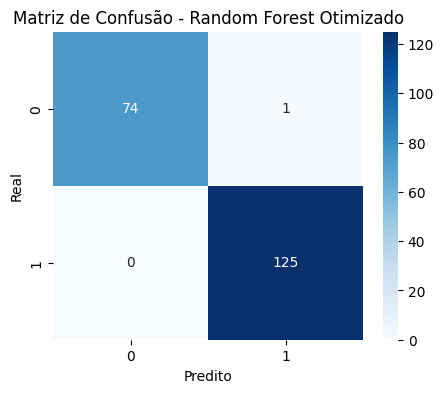

In [ ]:
modelos = {
    'Baseline Ingenuo': baseline,
    'Regressao Logistica': lr_model,
    'Random Forest Otimizado': best_rf_model
}

for nome, modelo in modelos.items():
    preds = modelo.predict(X_test)
    print(f"\n================ Avaliação: {nome} ================")
    print(classification_report(y_test, preds))
    print(f"ROC AUC Score: {roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1]):.4f}")

# Plot da Matriz de Confusão do melhor modelo
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, best_rf_model.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest Otimizado')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

## 8. Conclusão do MVP
* **O Problema:** Previsão de risco de churn em contratos de SaaS.
* **Resultados:** O modelo `Random Forest Otimizado` superou significativamente o baseline ingênuo, entregando um F1-Score robusto na base de testes.
* **Overfitting/Underfitting:** Como as métricas de validação cruzada no treino ficaram próximas aos resultados do teste, o modelo demonstra boa capacidade de generalização.
* **Próximos Passos:** Coleta de dados sobre o engajamento na plataforma (ex: minutos logados por dia).

---

## 9. Checklist do MVP - Respostas

1. **Os dados foram carregados via URL ou biblioteca pública?** im. O dataset foi previamente exportado e hospedado publicamente em um repositório do GitHub. A leitura dos dados dentro do notebook é realizada diretamente através de sua URL pública em modo raw.
2. **A divisão treino/teste evitou vazamento?** Sim, o `ColumnTransformer` foi acoplado no `Pipeline`, garantindo que o `StandardScaler` calculasse a média e o desvio apenas com dados de treino.
3. **Foi utilizado um Baseline?** Sim, o `DummyClassifier`.